In [1]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

os.environ['PYTHONHASHSEED'] = str(23092026)
random.seed(23092026)
np.random.seed(23092026)

import tensorflow as tf
tf.random.set_seed(23092026)

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import load_model

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report, confusion_matrix

I0000 00:00:1790239133.595885   81642 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790239133.634082   81642 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790239134.715359   81642 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Load the data

In [2]:
_, (X_test, y_test) = cifar10.load_data()
y_test = y_test.flatten()  # Eliminates 1D array scalar warnings

print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_test shape: (10000, 32, 32, 3)
y_test shape: (10000,)


# Data Visualization


Text(0.5, 1.0, 'Class distribution in testing set')

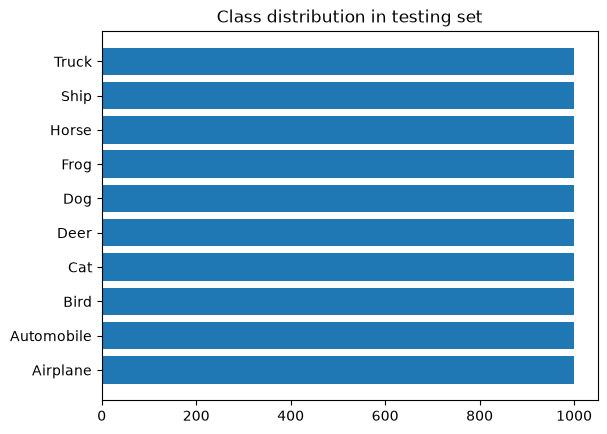

In [3]:
classes_name = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

classes, counts = np.unique(y_test, return_counts=True)
plt.barh(classes_name, counts)
plt.title('Class distribution in testing set')

The class are equally distributed


# Data Preprocessing


In [4]:
# Scale the data
X_test = X_test / 255.0

# Transform target variable into one-hotencoding
y_cat_test = to_categorical(y_test, 10)

print(f"X_test shape: {X_test.shape}")
print(f"y_cat_test shape: {y_cat_test.shape}")

X_test shape: (10000, 32, 32, 3)
y_cat_test shape: (10000, 10)


# Load Trained Model


In [5]:
model = load_model('custom_cnn_10_epochs.h5')
model.summary()

I0000 00:00:1790239137.337690   81642 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1088 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_60 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_60          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_61          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_62          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_63          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_64          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_65          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         1,29

 Total params: 552,364 (2.11 MB)

 Trainable params: 551,466 (2.10 MB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 2 (12.00 B)

# Model Evaluation


I0000 00:00:1790239138.840285   81722 service.cc:153] XLA service 0x77b8240383a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790239138.840308   81722 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.26.0)
I0000 00:00:1790239138.861824   81722 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1790239138.967172   81722 cuda_dnn.cc:461] Loaded cuDNN version 92600


 58/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7786 - loss: 0.6523 - precision: 0.8461 - recall: 0.7317

I0000 00:00:1790239141.721151   81722 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7792 - loss: 0.6642 - precision: 0.8452 - recall: 0.7282
Test Accuracy  : 77.92%
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


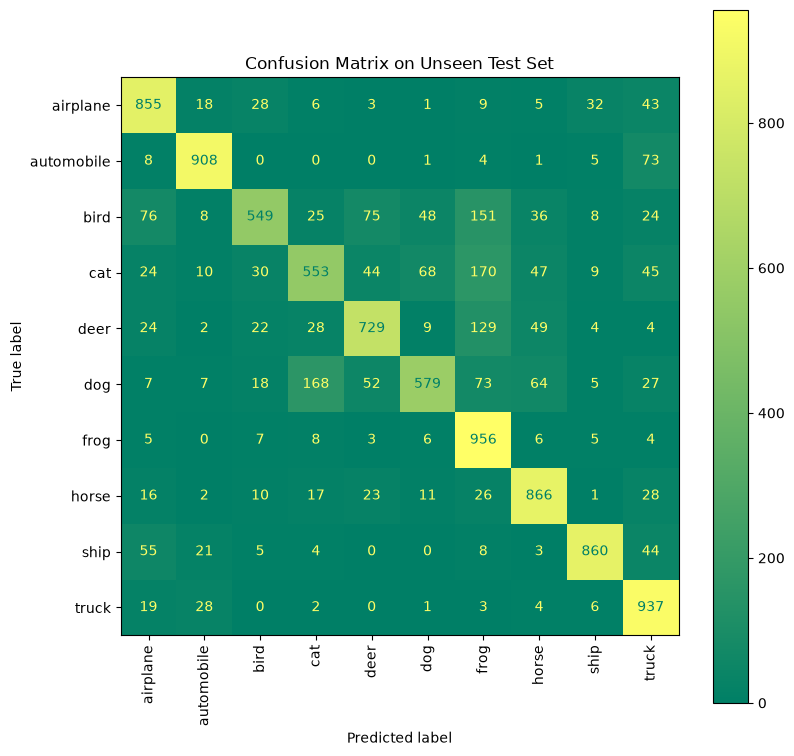

In [6]:
labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
          'dog', 'frog', 'horse', 'ship', 'truck']

# 1. Evaluate metrics on unseen test set
evaluation = model.evaluate(X_test, y_cat_test, verbose=1)
print(f'Test Accuracy  : {evaluation[1] * 100:.2f}%')

# 2. Single-pass inference across the complete test set
predictions = model.predict(X_test, batch_size=64, verbose=1)
y_pred = np.argmax(predictions, axis=1)

# 3. Confusion Matrix Display
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(xticks_rotation='vertical', ax=ax, cmap='summer')
plt.title('Confusion Matrix on Unseen Test Set', fontsize=12)
plt.show()

In [7]:
print(classification_report(y_test, y_pred, target_names=labels))


              precision    recall  f1-score   support

    airplane       0.79      0.85      0.82      1000
  automobile       0.90      0.91      0.91      1000
        bird       0.82      0.55      0.66      1000
         cat       0.68      0.55      0.61      1000
        deer       0.78      0.73      0.76      1000
         dog       0.80      0.58      0.67      1000
        frog       0.63      0.96      0.76      1000
       horse       0.80      0.87      0.83      1000
        ship       0.92      0.86      0.89      1000
       truck       0.76      0.94      0.84      1000

    accuracy                           0.78     10000
   macro avg       0.79      0.78      0.77     10000
weighted avg       0.79      0.78      0.77     10000



## Test on one image


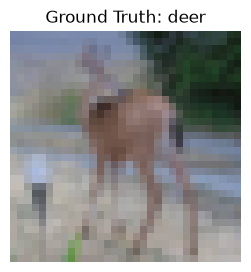

Image 100 Ground Truth Index: 4 (deer)
Model Prediction Index             : 4 (deer)


In [8]:
sample_idx = 100
my_image = X_test[sample_idx]

plt.figure(figsize=(3, 3))
plt.imshow(my_image)
plt.title(f"Ground Truth: {labels[y_test[sample_idx]]}")
plt.axis('off')
plt.show()

# Directly reuse the precomputed prediction array from Cell 6
pred_class_idx = np.argmax(predictions[sample_idx])
print(f"Image {sample_idx} Ground Truth Index: {y_test[sample_idx]} ({labels[y_test[sample_idx]]})")
print(f"Model Prediction Index             : {pred_class_idx} ({labels[pred_class_idx]})")

In [9]:
def plot_image(i, predictions_array, true_label, img):
    predictions_array, true_label, img = predictions_array, true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel(f"{labels[int(predicted_label)]} {100*np.max(predictions_array):2.0f}% ({labels[int(true_label)]})", 
               color=color)

def plot_value_array(i, predictions_array, true_label):
    predictions_array, true_label = predictions_array, int(true_label[i])
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)

    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')


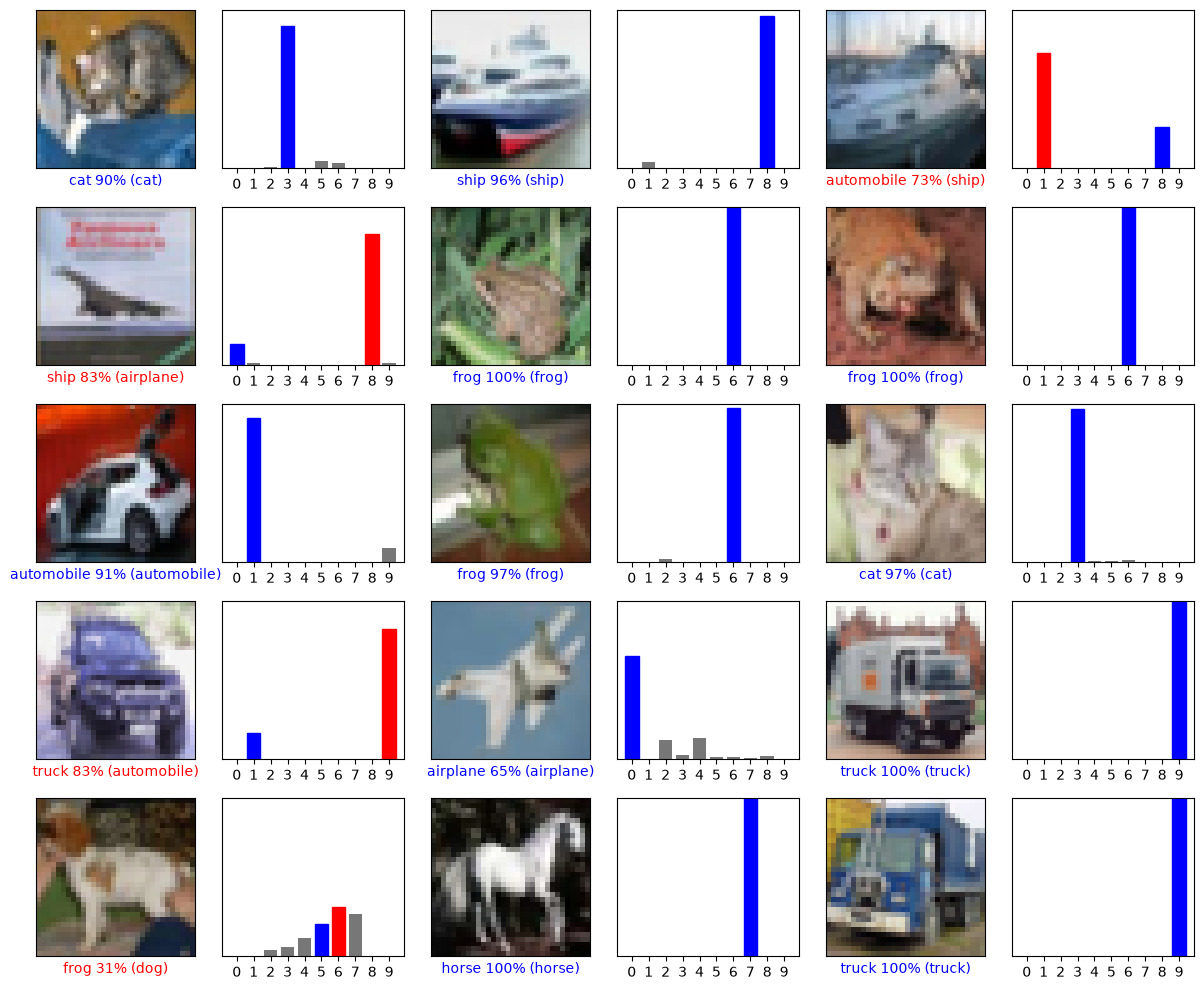

In [10]:
# Render predictions for 15 test samples using the cached predictions array
num_rows = 5
num_cols = 3
num_images = num_rows * num_cols

plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
    plot_image(i, predictions[i], y_test, X_test)
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 2)
    plot_value_array(i, predictions[i], y_test)

plt.tight_layout()
plt.show()